In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the data
config = pd.read_csv('experiments/models/dataset_size/experiment_config.csv')
results = pd.read_csv('experiments/results/dataset_size.csv')

In [3]:
results['experiment'] = results['model_id'].apply(lambda x: x.split('_')[-1])
results['experiment'] = results['experiment'].astype(int)

In [4]:
results['dataset'] = results['model_id'].apply(lambda x: x.split('_')[-5])
results = results[results['dataset'] != '1'] 
results = results[results['dataset'] != '2'] 
results = results[results['dataset'] != '3']
results['dataset'].unique()

array(['DavidEtAl', 'LiuEtAl', 'AllDatasets', 'NotGeo',
       'AllDatasetsAndNotGeo', 'LiuEtAlAndNotGeo'], dtype=object)

In [5]:
config = config[config['out_domain'] == 'yes']

In [6]:
config['dataset'].unique()

array(['DavidEtAl', 'LiuEtAl', 'AllDatasets', 'NotGeo',
       'AllDatasetsAndNotGeo', 'LiuEtAlAndNotGeo'], dtype=object)

In [7]:
# Merge the results and config DataFrames on the 'experiment' column
df = pd.merge(results, config, on=['experiment','dataset'], suffixes=('_results', '_config'))

In [8]:
df = df[(df['train_size'] == 0.9) & (df['val_size'] == 0.1)]

In [9]:
df['model'] = df['model_id'].apply(lambda x: x.split('_')[0])
# Create a new column 'dataset_quantity' as the product of 'dataset_size', 'train_size', and 'val_size'
df['train_size'] = df['train_size']*df['dataset_size']
df['val_size'] = df['val_size']*df['dataset_size']
df['dataset_size'] = df['train_size']+df['val_size']

In [ ]:
df

In [33]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import ast
import numpy as np

for idx, row_data in df.iterrows():
    # Convert string representations to actual list/array objects if needed
    if isinstance(row_data['gt_values'], str):
        gt_counts = np.array(ast.literal_eval(row_data['gt_values']))
        
    if isinstance(row_data['errors'], str):
        pred_counts = np.array(ast.literal_eval(row_data['errors']))+gt_counts
    
    # Calculate metrics
    r2 = r2_score(gt_counts, pred_counts)
    rmse = root_mean_squared_error(gt_counts, pred_counts)
    mape = mean_absolute_percentage_error(gt_counts, pred_counts) *100
    
    # Update the DataFrame with the metrics
    df.at[idx, 'r_squared'] = r2
    df.at[idx, 'rmse'] = rmse
    df.at[idx, 'mape'] = mape

/home/samuelebumbaca/miniforge3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/samuelebumbaca/miniforge3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/samuelebumbaca/miniforge3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/samuelebumbaca/miniforge3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/samuelebumbaca/miniforge3/

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model'])['r_squared'].idxmax()]

In [ ]:
df

102

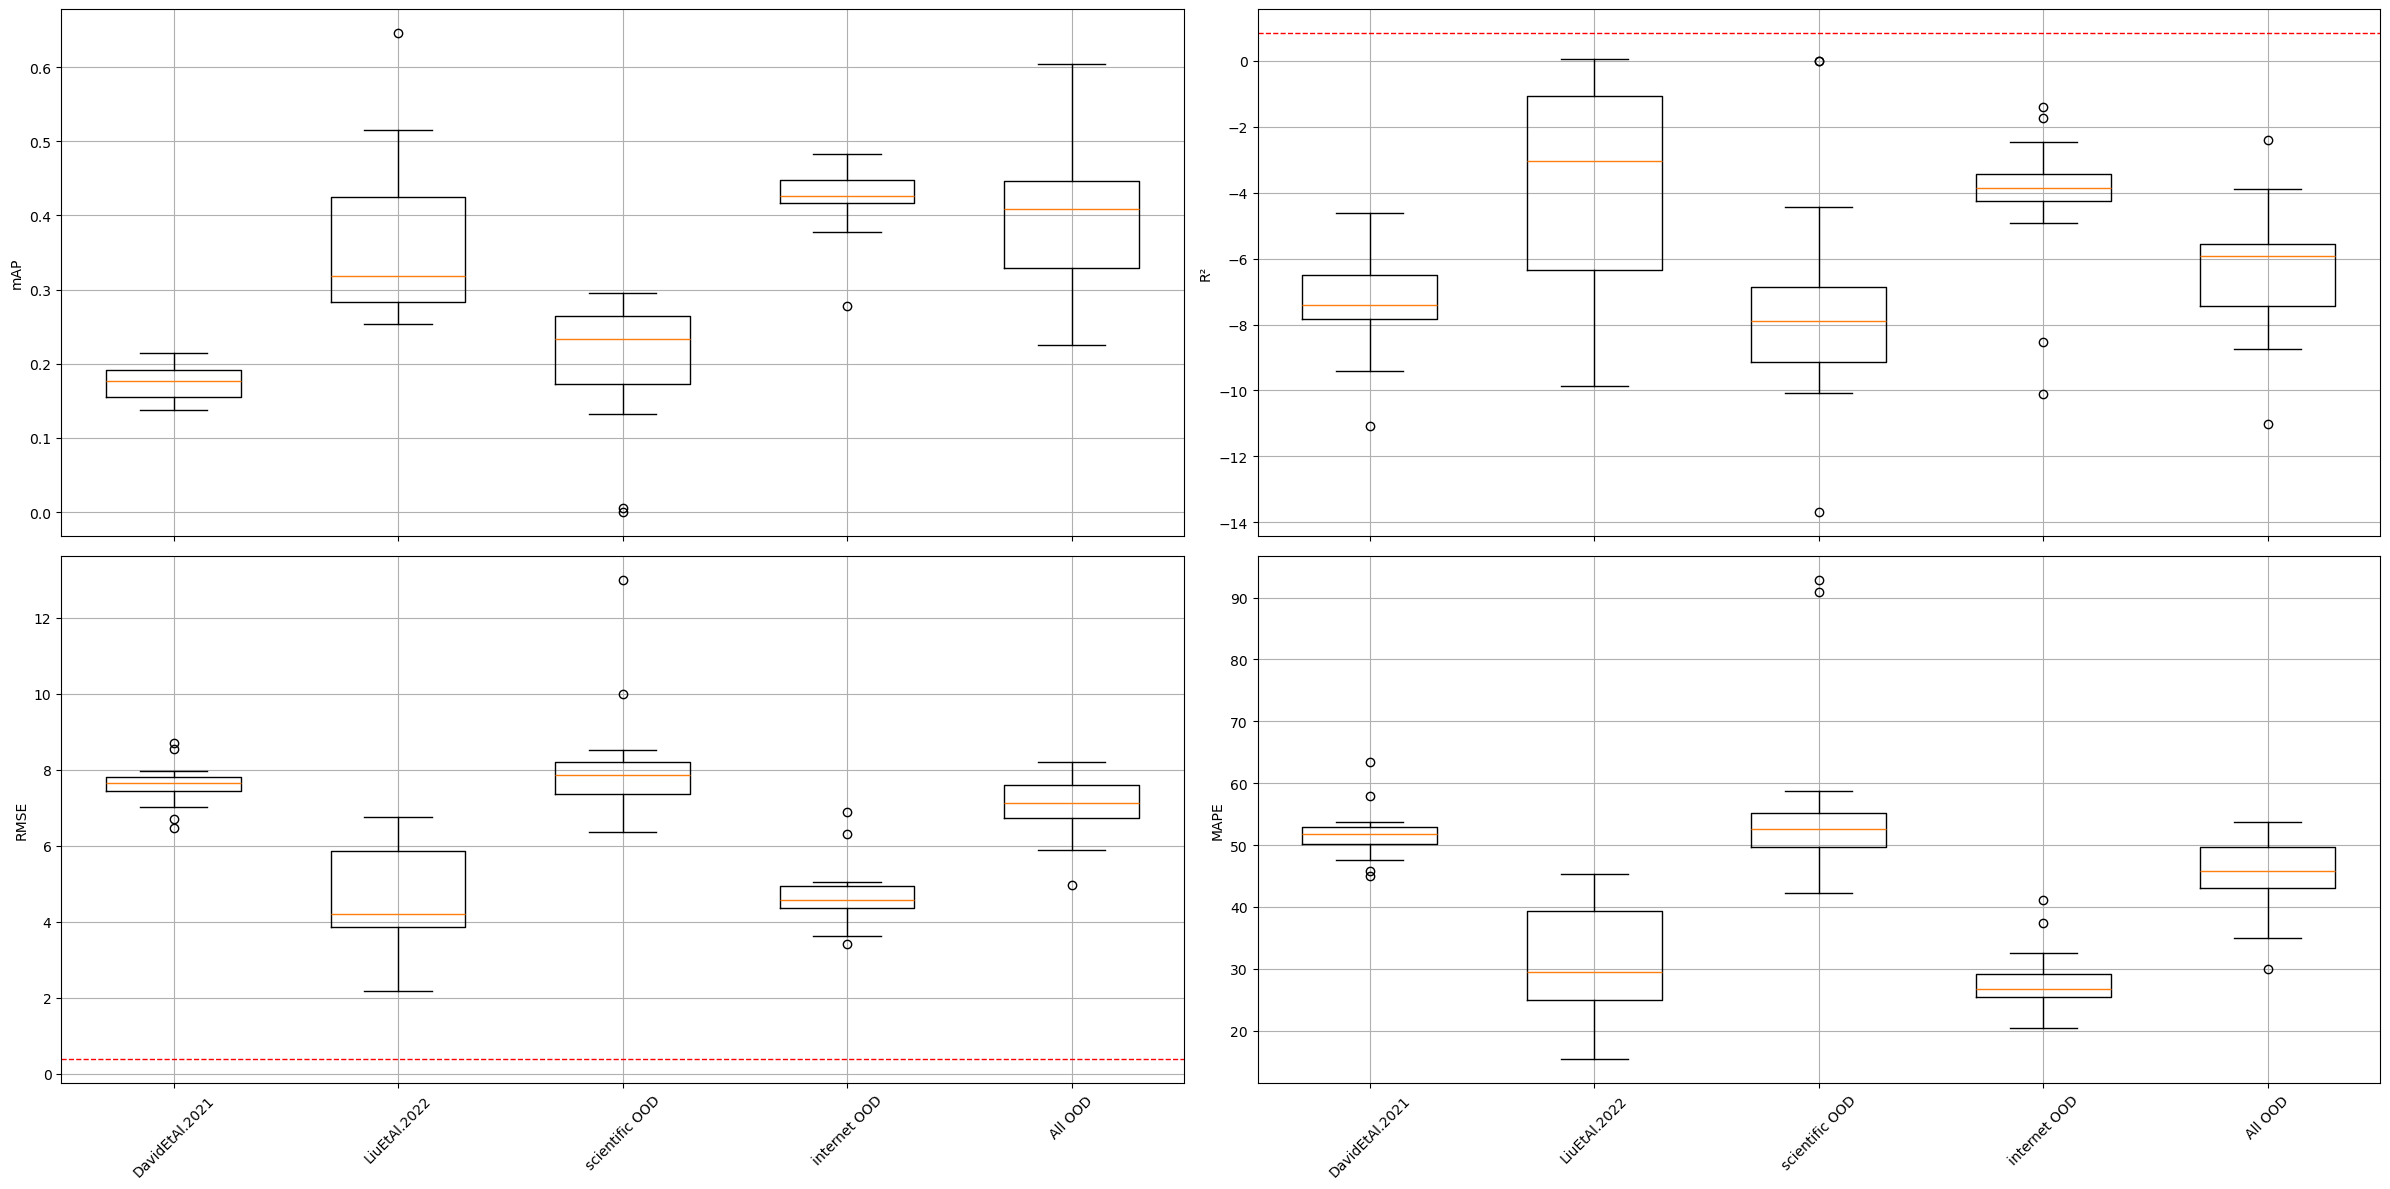

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model'])['r_squared'].idxmax()]

# Rename the datasets
filtered_df['dataset'] = filtered_df['dataset'].replace({
    'DavidEtAl': 'DavidEtAl.2021',
    'LiuEtAl': 'LiuEtAl.2022',
    'AllDatasets': 'scientific OOD',
    'NotGeo': 'internet OOD',
    'AllDatasetsAndNotGeo': 'All OOD',
})

# Exclude 'LiuEtAlAndNotGeo' from the DataFrame
filtered_df = filtered_df[filtered_df['dataset'] != 'LiuEtAlAndNotGeo']

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model'])['r_squared'].idxmax()]

# Define the order of datasets
ordered_datasets = ['DavidEtAl.2021', 'LiuEtAl.2022', 'scientific OOD', 'internet OOD', 'All OOD']

# Convert the 'dataset' column to a categorical type with the specified order
filtered_df['dataset'] = pd.Categorical(filtered_df['dataset'], categories=ordered_datasets, ordered=True)

# Sort the DataFrame by the 'dataset' column
filtered_df = filtered_df.sort_values('dataset')

# Function to plot a metric
def plot_metric(ax, metric, ylabel):
    datasets = filtered_df['dataset'].unique()
    positions = range(len(datasets))
    for i, dataset in enumerate(datasets):
        model_data = filtered_df[filtered_df['dataset'] == dataset]
        ax.boxplot(model_data[metric], positions=[i], widths=0.6)
    if metric == 'r_squared':
        ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    if metric == 'rmse':
        ax.axhline(y=0.39, color='red', linestyle='--', linewidth=1)
    ax.set_xticks(positions)
    ax.set_xticklabels(datasets, rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title('')
    ax.grid(True)

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(24, 12))

# Plot R-squared
plot_metric(axs[0, 0], 'ap_iou_50', 'mAP')

# Plot RMSE
plot_metric(axs[0, 1], 'r_squared', 'R²')

# Plot MAPE
plot_metric(axs[1, 0], 'rmse', 'RMSE')

# Plot mAP
plot_metric(axs[1, 1], 'mape', 'MAPE')

# Hide x-tick labels on top row
for ax in axs[0, :]:
    ax.tick_params(axis='x', labelbottom=False)
    
# Ensure x-tick labels are visible on bottom row (this is usually default)
for ax in axs[1, :]:
    ax.tick_params(axis='x', labelbottom=True)
    
# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('MDPI_template/Plots/metrics_OOD_datasets.pdf', format='pdf')

In [ ]:
filtered_df

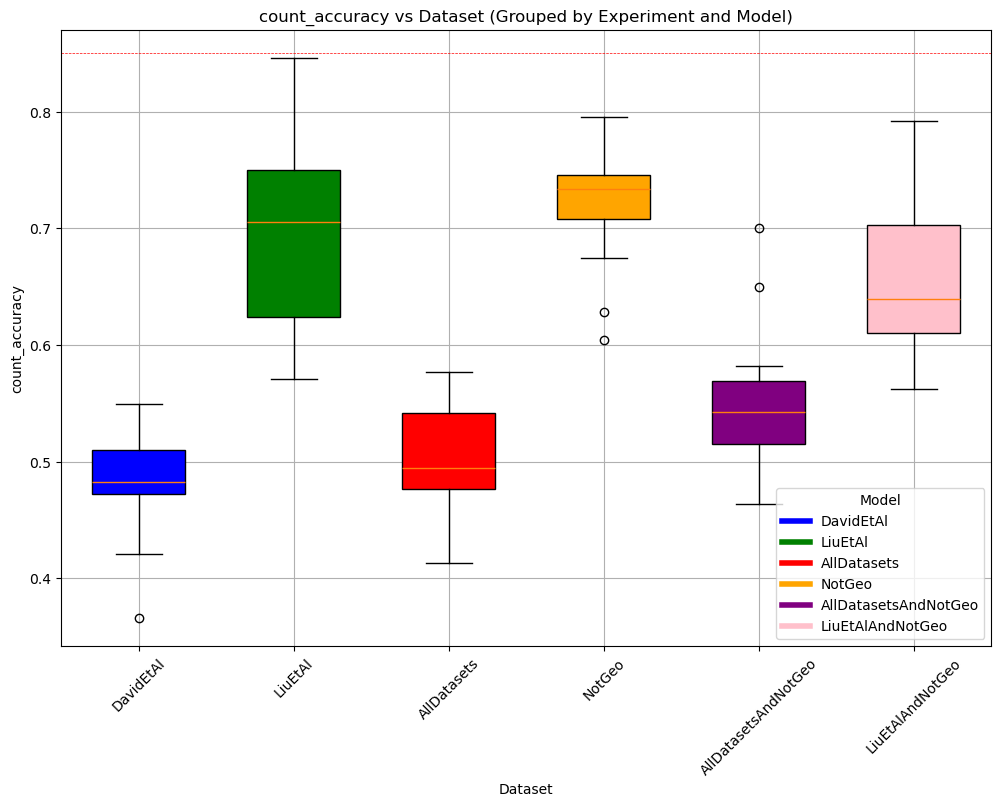

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['count_accuracy_avg'].idxmax()]

# Set r-squared <0 to 0
# filtered_df = filtered_df[filtered_df['count_accuracy_avg'] >= -1]

# Sort by dataset
# filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['count_accuracy_avg'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('count_accuracy')
plt.title('count_accuracy vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

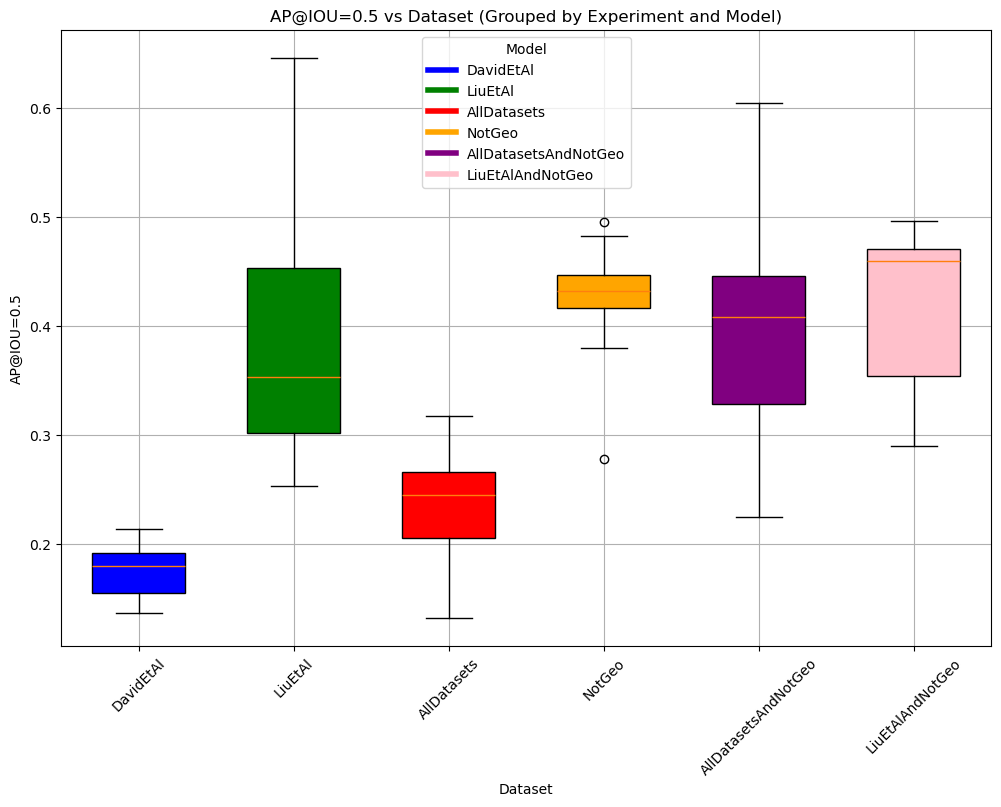

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['ap_iou_50'].idxmax()]

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['ap_iou_50'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    
plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('AP@IOU=0.5')
plt.title('AP@IOU=0.5 vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['ap_iou_50'].idxmax()]

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['ap_iou_50'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    
plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('AP@IOU=0.5')
plt.title('AP@IOU=0.5 vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

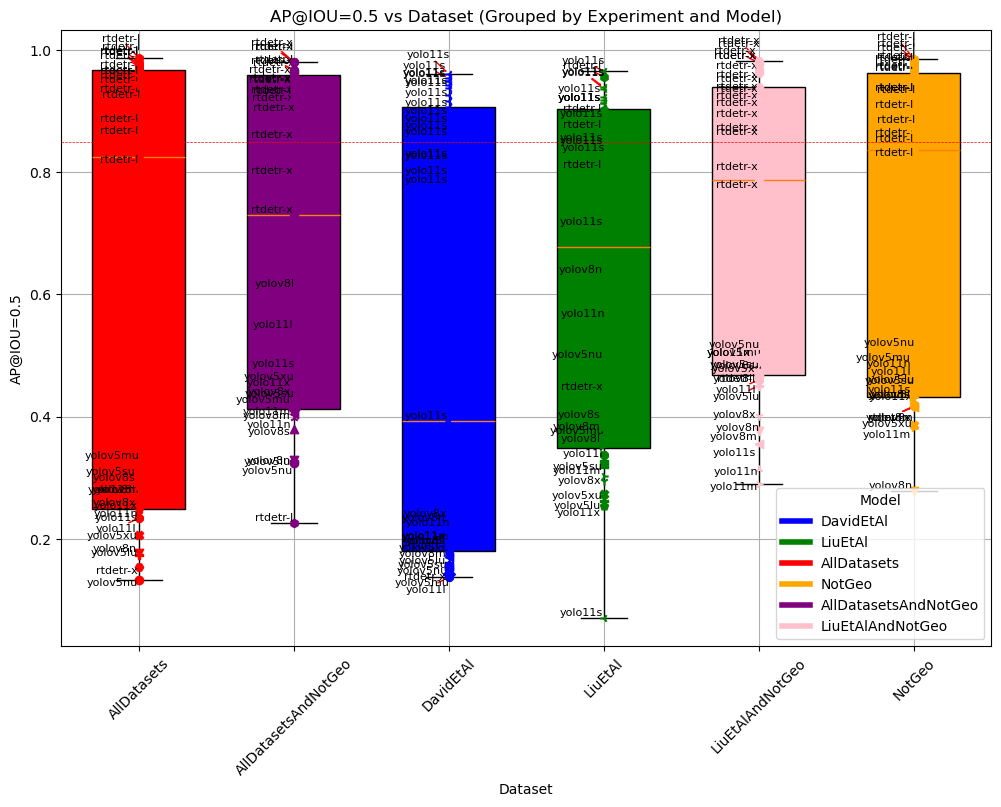

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'ap_iou_50' column to 0
filtered_df['ap_iou_50'] = filtered_df['ap_iou_50'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['ap_iou_50'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['ap_iou_50'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
texts = []
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['ap_iou_50'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['ap_iou_50'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        texts.append(plt.text(i, row['ap_iou_50'], row['model'], fontsize=8, ha='right'))

# Adjust text to avoid overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('AP@IOU=0.5')
plt.title('AP@IOU=0.5 vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

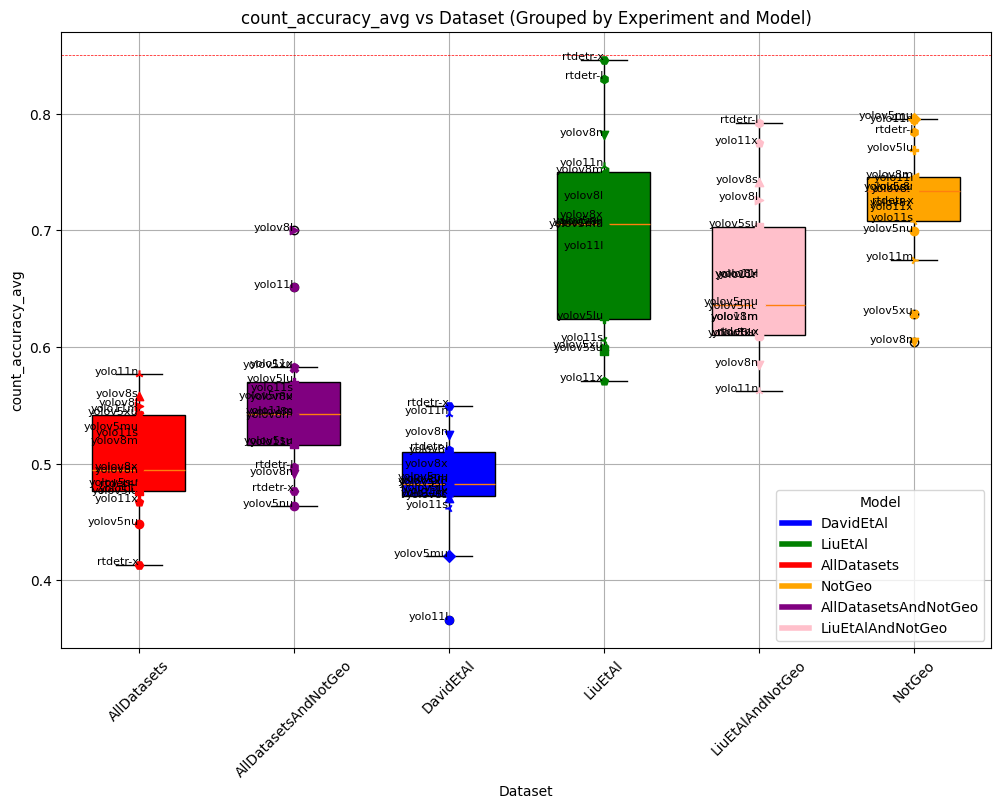

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'ap_iou_50' column to 0
filtered_df['ap_iou_50'] = filtered_df['ap_iou_50'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['count_accuracy_avg'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['count_accuracy_avg'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['count_accuracy_avg'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['count_accuracy_avg'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        plt.text(i, row['count_accuracy_avg'], row['model'], fontsize=8, ha='right')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('count_accuracy_avg')
plt.title('count_accuracy_avg vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

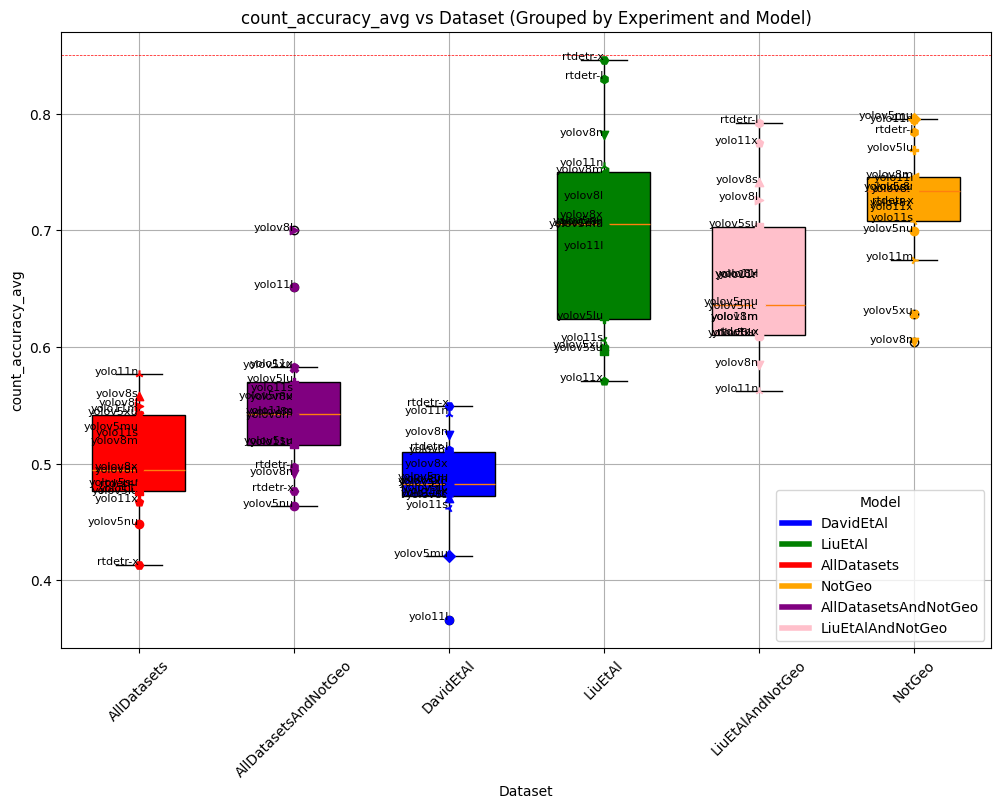

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'ap_iou_50' column to 0
filtered_df['ap_iou_50'] = filtered_df['ap_iou_50'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['count_accuracy_avg'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['count_accuracy_avg'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['count_accuracy_avg'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['count_accuracy_avg'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        plt.text(i, row['count_accuracy_avg'], row['model'], fontsize=8, ha='right')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('count_accuracy_avg')
plt.title('count_accuracy_avg vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

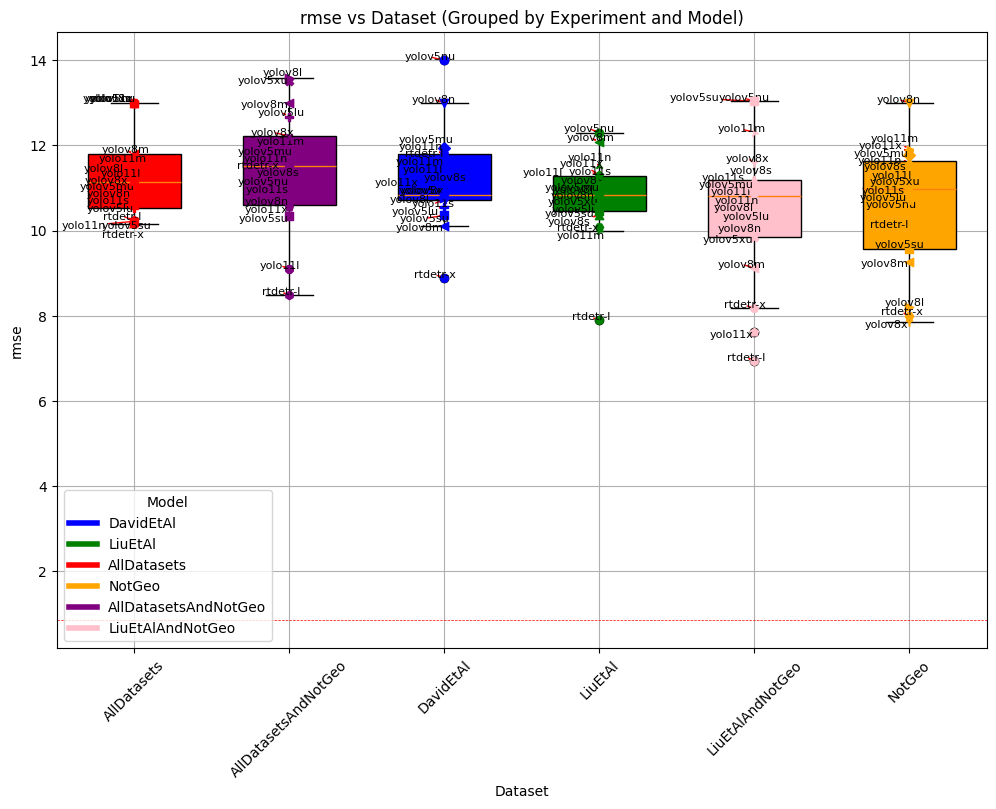

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'rmse' column to 0
filtered_df['rmse'] = filtered_df['rmse'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['rmse'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['rmse'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
texts = []
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['rmse'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['rmse'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        texts.append(plt.text(i, row['rmse'], row['model'], fontsize=8, ha='right'))

# Adjust text to avoid overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('rmse')
plt.title('rmse vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()